# Lab 1: EDA and cleaning (Riverside)

Inspect -> clean -> explore -> split -> encode and scale.
This follows the source lab's cleaning order. Full-data medians, modes and IQR
are used for descriptive EDA, so the whole workflow is not leakage-free.
For a predictive evaluation, split before learning those cleaning statistics too.
The bundled CSV is the source lab's generated practice dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

RANDOM_STATE = 42


## 1. Inspect

In [2]:
raw = pd.read_csv("riverside_cases.csv", keep_default_na=False, na_values=[""])
print("Shape:", raw.shape)
print("Missing cells:", int(raw.isna().sum().sum()))
print("Duplicates:", int(raw.duplicated().sum()))
raw.info()
print(raw.isna().sum())
raw.head()


Shape: (368, 11)
Missing cells: 92
Duplicates: 8
<class 'pandas.DataFrame'>
RangeIndex: 368 entries, 0 to 367
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   crime_type          359 non-null    str    
 1   borough             361 non-null    str    
 2   date_reported       358 non-null    str    
 3   time_of_day         360 non-null    str    
 4   suspect_age         354 non-null    float64
 5   weapon_used         357 non-null    str    
 6   witness_count       360 non-null    float64
 7   evidence_count      361 non-null    float64
 8   officer_experience  362 non-null    float64
 9   response_time       356 non-null    float64
 10  case_status         368 non-null    str    
dtypes: float64(5), str(6)
memory usage: 31.8 KB
crime_type             9
borough                7
date_reported         10
time_of_day            8
suspect_age           14
weapon_used           11
witness_count        

,crime_type,borough,date_reported,time_of_day,suspect_age,weapon_used,witness_count,evidence_count,officer_experience,response_time,case_status
0,Theft,CENTRAL,2024-11-13,afternoon,30.0,Blunt Object,2.0,2.0,22.0,10.3,Solved
1,Burglary,North,08/09/2024,night,51.0,NONE,2.0,3.0,8.0,17.8,SOLVED
2,Vandalism,CENTRAL,"Dec 15, 2025",Morning,35.0,None,0.0,2.0,13.0,12.3,Solved
3,theft,central,06-30-2025,morning,48.0,firearm,0.0,4.0,9.0,76.0,UNSOLVED
4,Burglary,WEST,2025-05-15,MORNING,42.0,Knife,0.0,4.0,22.0,11.5,Solved


## 2. Clean (on a copy)

In [3]:
df = raw.copy()
df = df.drop_duplicates().reset_index(drop=True)

cat_cols = ["crime_type","borough","time_of_day","weapon_used","case_status"]
for c in cat_cols:
    df[c] = df[c].astype("string").str.strip().str.title()

df = df.dropna(subset=["case_status"]).reset_index(drop=True)   # drop rows missing TARGET

df["date_reported"] = pd.to_datetime(df["date_reported"], format="mixed", dayfirst=True, errors="coerce")

num_cols = ["suspect_age","witness_count","evidence_count","officer_experience","response_time"]
for c in num_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")
df.loc[~df["suspect_age"].between(10,100), "suspect_age"] = np.nan   # impossible ages -> NaN

for c in ["witness_count", "evidence_count", "officer_experience"]:
    df.loc[df[c] < 0, c] = np.nan
df.loc[df["response_time"] <= 0, "response_time"] = np.nan

# impute features (numeric->median, categorical->mode, date->median date)
for c in num_cols:
    df[c] = df[c].fillna(df[c].median())
for c in ["crime_type","borough","time_of_day","weapon_used"]:
    df[c] = df[c].fillna(df[c].mode()[0])
df["date_reported"] = df["date_reported"].fillna(df["date_reported"].dropna().median())

for c in ["suspect_age", "witness_count", "evidence_count", "officer_experience"]:
    df[c] = df[c].round().astype(int)

# cap response_time outliers (Tukey 1.5*IQR)
Q1, Q3 = df["response_time"].quantile([0.25,0.75])
IQR = Q3-Q1
df["response_time"] = df["response_time"].clip(Q1-1.5*IQR, Q3+1.5*IQR)

print("Clean shape:", df.shape, "| missing:", int(df.isna().sum().sum()))


Clean shape: (360, 11) | missing: 0


## 3. Explore

       suspect_age  witness_count  evidence_count  officer_experience  \
count   360.000000     360.000000      360.000000          360.000000   
mean     35.236111       1.538889        2.819444           11.433333   
std      12.591828       1.353275        1.707972            5.864391   
min      14.000000       0.000000        0.000000            1.000000   
25%      27.000000       1.000000        1.750000            7.000000   
50%      35.000000       1.000000        3.000000           12.000000   
75%      43.000000       2.000000        4.000000           15.000000   
max      76.000000       6.000000        8.000000           29.000000   

       response_time  
count     360.000000  
mean       14.845521  
std         5.262114  
min         5.100000  
25%        11.400000  
50%        13.700000  
75%        17.925000  
max        27.712500  
case_status
Solved      0.558
Unsolved    0.442
Name: proportion, dtype: Float64


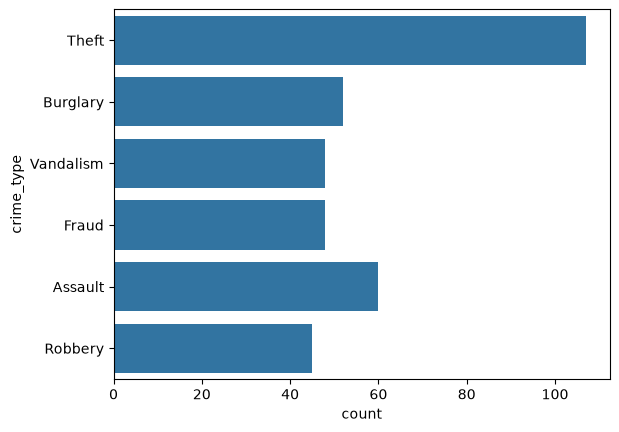

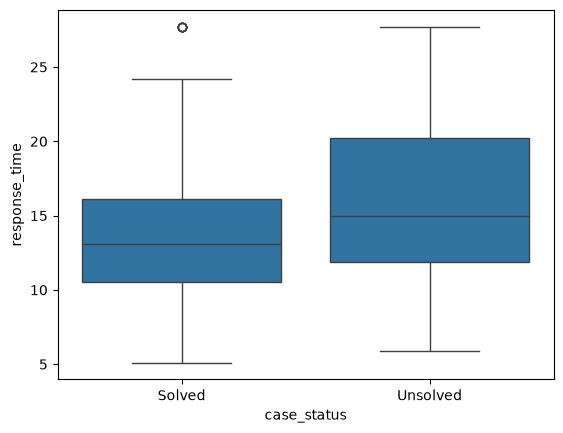

In [4]:
print(df[num_cols].describe())
print(df["case_status"].value_counts(normalize=True).round(3))
sns.countplot(data=df, y="crime_type")
plt.show()
sns.boxplot(data=df, x="case_status", y="response_time")
plt.show()


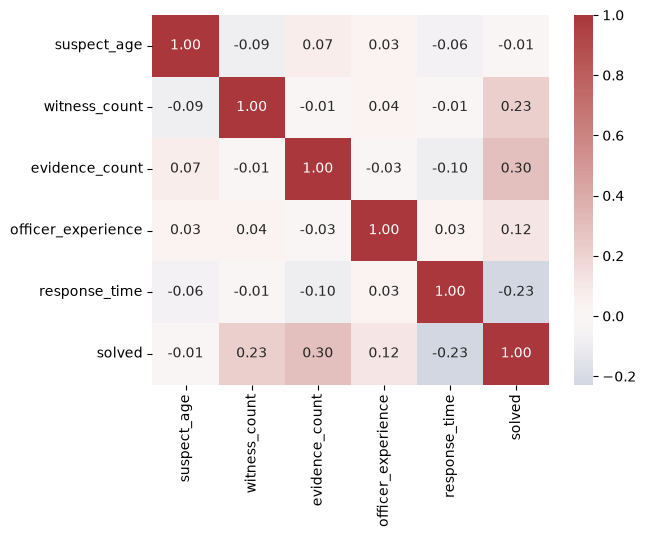

In [5]:
tmp = df[num_cols].copy()
tmp["solved"] = df["case_status"].map({"Solved":1,"Unsolved":0})
sns.heatmap(tmp.corr(), annot=True, fmt=".2f", cmap="vlag", center=0)
plt.show()


## 4. Split, then fit the encoder and scaler on training rows

In [6]:
# derive date parts as extra numeric features
df["year"] = df["date_reported"].dt.year
df["month"] = df["date_reported"].dt.month
df["dayofweek"] = df["date_reported"].dt.dayofweek

X = df.drop(columns=["case_status","date_reported"])
y = df["case_status"].map({"Solved":1,"Unsolved":0})

numeric_features = num_cols + ["year","month","dayofweek"]
categorical_features = ["crime_type","borough","time_of_day","weapon_used"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

num_pipe = Pipeline([("imp", SimpleImputer(strategy="median")), ("sc", StandardScaler())])
cat_pipe = Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                     ("ohe", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
pre = ColumnTransformer([("num", num_pipe, numeric_features),
                         ("cat", cat_pipe, categorical_features)])

X_train_p = pre.fit_transform(X_train)
X_test_p  = pre.transform(X_test)
print("Train:", X_train_p.shape, "| Test:", X_test_p.shape)


Train: (288, 28) | Test: (72, 28)
